# IE493 Project — Phase 3: Integrated System (Network Flow)

**Group 12** — Erdoğan Kocabaş (2021402183) & Berru Selcan Cocen (2021402003)

---

## Overview

Phase 3 extends the Phase 2 preemptive-resume ER simulation by integrating a **Diagnostic Lab** (Node 2).
Upon completing Doctor treatment, ~40% of patients proceed to the Lab.
The Lab operates on an FCFS basis with a fixed capacity of 3 machines, ignoring priority status.
We will analyze the total cycle time (Door-to-Door), verify lab constraints, and perform capacity planning to meet performance targets.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import heapq
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# ── Constants ──
RED, YELLOW, GREEN = 1, 2, 3
PRIORITY_MAP   = {'Red': RED, 'Yellow': YELLOW, 'Green': GREEN}
PRIORITY_NAMES = {RED: 'Red', YELLOW: 'Yellow', GREEN: 'Green'}
PRIORITY_COLORS = {'Red': '#e74c3c', 'Yellow': '#f39c12', 'Green': '#27ae60'}


# 1. Data Loading & Preprocessing

Load the Group 12 Phase 3 dataset. This dataset includes `Needs_Lab` and `Lab_Service_Required_Min`.


In [2]:
def min_to_clock(minutes):
    """Convert minutes from 08:00:00 to HH:MM:SS clock string."""
    if np.isnan(minutes):
        return ""
    total_sec = round(minutes * 60)
    base_sec  = 8 * 3600  # 08:00:00
    total_sec += base_sec

    day = total_sec // 86400
    rem = total_sec % 86400
    h   = rem // 3600
    mi  = (rem % 3600) // 60
    s   = rem % 60

    clock = f"{h:02d}:{mi:02d}:{s:02d}"
    if day > 0:
        return f"Day{day + 1} {clock}"
    return clock

# Load dataset
df = pd.read_csv('Group_12/ER_Phase3_Group_12.csv')
print(f"Loaded {len(df)} patients")

# Parse Arrival_Clock -> minutes from 08:00
ER_OPEN_HOUR = 8  # 08:00
day_offset = 0
prev_total_sec = -1
arrival_minutes = []

for t_str in df['Arrival_Clock']:
    parts = t_str.strip().split(':')
    h, m, s = int(parts[0]), int(parts[1]), int(parts[2])
    total_sec = h * 3600 + m * 60 + s

    if prev_total_sec >= 0 and total_sec < prev_total_sec - 3600:
        day_offset += 1
    prev_total_sec = total_sec

    minutes_from_open = (day_offset * 24 * 60) + (h * 60 + m + s / 60.0) - (ER_OPEN_HOUR * 60)
    arrival_minutes.append(minutes_from_open)

df['arrival_min'] = arrival_minutes
df['priority_num'] = df['Priority'].map(PRIORITY_MAP)

print("Needs_Lab distribution:")
print(df['Needs_Lab'].value_counts().to_string())
print()
print("Lab Service Time (for those who need it):")
print(df.loc[df['Needs_Lab'], 'Lab_Service_Required_Min'].describe())

df.head()


Loaded 1000 patients
Needs_Lab distribution:
Needs_Lab
False    601
True     399

Lab Service Time (for those who need it):
count    399.000000
mean      24.760401
std        7.184249
min       10.640000
25%       19.625000
50%       23.840000
75%       28.715000
max       52.910000
Name: Lab_Service_Required_Min, dtype: float64


,Patient_ID,Arrival_Clock,Priority,Service_Required_Min,Needs_Lab,Lab_Service_Required_Min,arrival_min,priority_num
0,1000,08:00:41,Green,10.45,True,31.1,0.683333,3
1,1001,08:11:00,Green,19.92,False,0.0,11.000000,3
2,1002,08:11:01,Green,8.08,False,0.0,11.016667,3
3,1003,08:13:45,Green,11.69,True,27.4,13.750000,3
4,1004,08:14:21,Green,12.90,False,0.0,14.350000,3


# 2. Integrated Simulation Engine (Doctors + Lab)

We extend the event-driven min-heap simulation from Phase 2.
Events are processed in chronological order:
1. `LAB_COMPLETION`: Lab machine freed, pull next patient from FCFS lab queue.
2. `DOC_COMPLETION`: Doctor freed, pull next from doctor priority queue. If completing patient needs lab, they are immediately routed to the lab (either starting lab service or joining the lab queue).
3. `ARRIVAL`: Patient arrives at the hospital.

Doctor logic follows Phase 2 (Preemptive-Resume).
Lab logic follows Phase 3 (FCFS, no priority).


In [3]:
def simulate_network_flow(df, s_dr=5, s_lab=3, verbose=False):
    # ── Event type constants ──
    # Order matters for tie-breaking at same timestamp
    EVT_LAB_COMPLETION = 0
    EVT_DOC_COMPLETION = 1
    EVT_ARRIVAL        = 2

    n = len(df)

    # ── Extract arrays for speed ──
    arrival   = df['arrival_min'].values.astype(float)
    priority  = df['priority_num'].values.astype(int)
    doc_service = df['Service_Required_Min'].values.astype(float)
    needs_lab = df['Needs_Lab'].values.astype(bool)
    lab_service = df['Lab_Service_Required_Min'].values.astype(float)
    pat_ids   = df['Patient_ID'].values

    # ── Patient state ──
    remaining_work       = doc_service.copy()
    interruptions        = np.zeros(n, dtype=int)
    doc_first_start      = np.full(n, np.nan)
    doc_final_end        = np.full(n, np.nan)
    lab_start            = np.full(n, np.nan)
    lab_end              = np.full(n, np.nan)
    docs_busy_on_arrival = np.zeros(n, dtype=int)

    # ── Node 1: Doctor state ──
    doc_busy       = [False] * s_dr
    doc_patient    = [None]  * s_dr
    doc_busy_until = [0.0]   * s_dr
    doc_version    = [0]     * s_dr
    doc_wait_q = {RED: deque(), YELLOW: deque(), GREEN: deque()}

    # ── Node 2: Lab state ──
    lab_busy       = [False] * s_lab
    lab_patient    = [None]  * s_lab
    lab_version    = [0]     * s_lab
    lab_wait_q     = deque() # FCFS

    # ── Event queue (min-heap) ──
    # Format: (time, event_type, tiebreak, pat_idx, res_idx, version)
    event_q = []
    for i in range(n):
        heapq.heappush(event_q, (arrival[i], EVT_ARRIVAL, i, i, -1, -1))

    event_counter = n
    total_preemptions = 0
    
    # Track utilization areas
    doc_busy_time_area = 0.0
    lab_busy_time_area = 0.0
    last_event_time = 0.0

    def update_areas(t):
        nonlocal doc_busy_time_area, lab_busy_time_area, last_event_time
        dt = t - last_event_time
        if dt > 0:
            doc_busy_time_area += sum(doc_busy) * dt
            lab_busy_time_area += sum(lab_busy) * dt
        last_event_time = t

    # ── Helpers for Node 2 (Lab) ──
    def assign_to_lab(pat_idx, machine_idx, t):
        nonlocal event_counter
        svc_duration = lab_service[pat_idx]
        lab_busy[machine_idx] = True
        lab_patient[machine_idx] = pat_idx
        lab_version[machine_idx] += 1
        lab_start[pat_idx] = t
        
        heapq.heappush(event_q, (
            t + svc_duration, EVT_LAB_COMPLETION, event_counter, 
            pat_idx, machine_idx, lab_version[machine_idx]
        ))
        event_counter += 1

    def route_to_lab(pat_idx, t):
        if not needs_lab[pat_idx]:
            return
        
        # Try find free lab machine
        idle_mac = None
        for j in range(s_lab):
            if not lab_busy[j]:
                idle_mac = j
                break
                
        if idle_mac is not None:
            assign_to_lab(pat_idx, idle_mac, t)
        else:
            lab_wait_q.append(pat_idx)

    # ── Helpers for Node 1 (Doctor) ──
    def assign_to_doctor(pat_idx, doc_idx, t):
        nonlocal event_counter
        svc_duration = remaining_work[pat_idx]
        doc_busy[doc_idx]       = True
        doc_patient[doc_idx]    = pat_idx
        doc_busy_until[doc_idx] = t + svc_duration
        doc_version[doc_idx]   += 1

        if np.isnan(doc_first_start[pat_idx]):
            doc_first_start[pat_idx] = t

        heapq.heappush(event_q, (
            t + svc_duration, EVT_DOC_COMPLETION, event_counter,
            pat_idx, doc_idx, doc_version[doc_idx]
        ))
        event_counter += 1

    def pull_from_doc_queue():
        for prio in [RED, YELLOW, GREEN]:
            if doc_wait_q[prio]:
                return doc_wait_q[prio].popleft()
        return None

    def find_idle_doctor():
        for j in range(s_dr):
            if not doc_busy[j]:
                return j
        return None

    # ═════ MAIN EVENT LOOP ═════
    while event_q:
        t, etype, _, pat_idx, res_idx, ver = heapq.heappop(event_q)
        update_areas(t)

        if etype == EVT_LAB_COMPLETION:
            if lab_version[res_idx] != ver: continue
            
            lab_end[pat_idx] = t
            lab_busy[res_idx] = False
            lab_patient[res_idx] = None
            
            if lab_wait_q:
                next_pat = lab_wait_q.popleft()
                assign_to_lab(next_pat, res_idx, t)

        elif etype == EVT_DOC_COMPLETION:
            if doc_version[res_idx] != ver: continue
            
            doc_final_end[pat_idx] = t
            doc_busy[res_idx] = False
            doc_patient[res_idx] = None
            
            # Route to lab if needed
            route_to_lab(pat_idx, t)
            
            next_pat = pull_from_doc_queue()
            if next_pat is not None:
                assign_to_doctor(next_pat, res_idx, t)

        elif etype == EVT_ARRIVAL:
            pri = priority[pat_idx]
            docs_busy_on_arrival[pat_idx] = sum(doc_busy)

            idle_doc = find_idle_doctor()
            if idle_doc is not None:
                assign_to_doctor(pat_idx, idle_doc, t)
                continue

            if pri != RED:
                doc_wait_q[pri].append(pat_idx)
                continue

            # RED PREEMPTION ATTEMPT
            candidates = [j for j in range(s_dr) if doc_busy[j] and priority[doc_patient[j]] == GREEN]
            if not candidates:
                candidates = [j for j in range(s_dr) if doc_busy[j] and priority[doc_patient[j]] == YELLOW]

            if not candidates:
                doc_wait_q[RED].append(pat_idx)
                continue

            victim_doc = min(candidates, key=lambda j: doc_busy_until[j])
            victim_pat = doc_patient[victim_doc]

            # CALCULATE REMAINING WORK
            remaining = doc_busy_until[victim_doc] - t
            remaining_work[victim_pat] = remaining
            interruptions[victim_pat] += 1
            total_preemptions += 1

            victim_pri = priority[victim_pat]
            doc_wait_q[victim_pri].appendleft(victim_pat)

            assign_to_doctor(pat_idx, victim_doc, t)

    # ═════ BUILD RESULTS ═════
    doc_W  = doc_final_end - arrival
    doc_Wq = doc_W - doc_service

    # Door to door calculation
    final_exit = np.where(needs_lab, lab_end, doc_final_end)
    door_to_door = final_exit - arrival

    lab_W = np.where(needs_lab, lab_end - doc_final_end, np.nan)
    lab_Wq = np.where(needs_lab, lab_start - doc_final_end, np.nan)

    results = pd.DataFrame({
        'Patient_ID':         pat_ids,
        'Priority':           [PRIORITY_NAMES[p] for p in priority],
        'Needs_Lab':          needs_lab,
        'Arrival_Min':        arrival,
        
        'Doc_Start_Min':      doc_first_start,
        'Doc_End_Min':        doc_final_end,
        'Interruptions':      interruptions,
        'Doc_Service':        doc_service,
        'Doc_Wq':             doc_Wq,
        'Doc_W':              doc_W,
        
        'Lab_Queue_Entry':    np.where(needs_lab, doc_final_end, np.nan),
        'Lab_Start_Min':      lab_start,
        'Lab_End_Min':        lab_end,
        'Lab_Service':        lab_service,
        'Lab_Wq':             lab_Wq,
        'Lab_W':              lab_W,
        
        'Door_to_Door':       door_to_door
    })

    sim_end_time = max(np.nanmax(doc_final_end), np.nanmax(lab_end))
    metrics = {
        'total_preemptions': total_preemptions,
        'sim_end_time': sim_end_time,
        'doc_rho': doc_busy_time_area / (s_dr * sim_end_time),
        'lab_rho': lab_busy_time_area / (s_lab * sim_end_time)
    }

    return results, metrics


# 3. Sanity Checks & Validation

We run the integrated simulation and perform sanity checks to ensure the timeline and constraints are valid.


In [4]:
res, metrics = simulate_network_flow(df, s_dr=5, s_lab=3)

print("--- Sanity Checks ---")
print(f"[PASS] All 1000 patients completed doctor treatment: {res['Doc_End_Min'].notna().all()}")
lab_mask = res['Needs_Lab']
print(f"[PASS] All {lab_mask.sum()} lab patients completed lab: {res.loc[lab_mask, 'Lab_End_Min'].notna().all()}")

# Timeline consistency
timeline_doc_ok = (res['Doc_Start_Min'] >= res['Arrival_Min'] - 1e-9).all() and                   (res['Doc_End_Min'] >= res['Doc_Start_Min'] - 1e-9).all()
print(f"[PASS] Doctor timeline consistent: {timeline_doc_ok}")

timeline_lab_ok = (res.loc[lab_mask, 'Lab_Start_Min'] >= res.loc[lab_mask, 'Lab_Queue_Entry'] - 1e-9).all() and                   (res.loc[lab_mask, 'Lab_End_Min'] >= res.loc[lab_mask, 'Lab_Start_Min'] - 1e-9).all()
print(f"[PASS] Lab timeline consistent: {timeline_lab_ok}")

# FCFS constraint in Lab
lab_pts = res[lab_mask].sort_values('Lab_Start_Min')
fcfs_ok = lab_pts['Lab_Queue_Entry'].is_monotonic_increasing
print(f"[PASS] Lab FCFS strictly maintained (no priorities in lab): {fcfs_ok}")

print()
print(f"Overall Doctor Traffic Intensity (rho_dr): {metrics['doc_rho']:.4f}")
print(f"Overall Lab Traffic Intensity (rho_lab): {metrics['lab_rho']:.4f}")


--- Sanity Checks ---
[PASS] All 1000 patients completed doctor treatment: True
[PASS] All 399 lab patients completed lab: True
[PASS] Doctor timeline consistent: True
[PASS] Lab timeline consistent: True
[PASS] Lab FCFS strictly maintained (no priorities in lab): True

Overall Doctor Traffic Intensity (rho_dr): 0.7443
Overall Lab Traffic Intensity (rho_lab): 0.7926


# 4. Deliverable 1: Node 2 Integration Results (Simulation Log)

An output table for the first 25 patients showing timing information across both nodes.


In [5]:
log_25 = res.head(25).copy()

for col in ['Arrival_Min', 'Doc_Start_Min', 'Doc_End_Min', 'Lab_Start_Min', 'Lab_End_Min']:
    log_25[col.replace('_Min', '_Clock')] = log_25[col].apply(min_to_clock)

display_cols = [
    'Patient_ID', 'Priority', 'Needs_Lab', 'Arrival_Clock',
    'Doc_Start_Clock', 'Doc_End_Clock', 'Interruptions', 'Doc_Service', 'Doc_Wq',
    'Lab_Start_Clock', 'Lab_End_Clock', 'Lab_Service', 'Lab_Wq',
    'Door_to_Door'
]

display_table = log_25[display_cols].copy()
for col in ['Doc_Service', 'Doc_Wq', 'Lab_Service', 'Lab_Wq', 'Door_to_Door']:
    display_table[col] = display_table[col].round(2)

print("=" * 140)
print("SIMULATION LOG - FIRST 25 PATIENTS (Nodes 1 & 2)")
print("=" * 140)
display(display_table.fillna('-'))


SIMULATION LOG - FIRST 25 PATIENTS (Nodes 1 & 2)


,Patient_ID,Priority,Needs_Lab,Arrival_Clock,Doc_Start_Clock,Doc_End_Clock,Interruptions,Doc_Service,Doc_Wq,Lab_Start_Clock,Lab_End_Clock,Lab_Service,Lab_Wq,Door_to_Door
0,1000,Green,True,08:00:41,08:00:41,08:11:08,0,10.45,0.0,08:11:08,08:42:14,31.10,0.0,41.55
1,1001,Green,False,08:11:00,08:11:00,08:30:55,0,19.92,0.0,,,0.00,-,19.92
2,1002,Green,False,08:11:01,08:11:01,08:19:06,0,8.08,-0.0,,,0.00,-,8.08
3,1003,Green,True,08:13:45,08:13:45,08:25:26,0,11.69,-0.0,08:25:26,08:52:50,27.40,0.0,39.09
4,1004,Green,False,08:14:21,08:14:21,08:27:15,0,12.90,-0.0,,,0.00,-,12.90
5,1005,Yellow,False,08:21:19,08:21:19,08:32:32,0,11.21,0.0,,,0.00,-,11.21
6,1006,Green,False,08:26:18,08:26:18,08:35:34,0,9.26,-0.0,,,0.00,-,9.26
7,1007,Green,False,08:38:39,08:38:39,08:47:43,0,9.07,0.0,,,0.00,-,9.07
8,1008,Green,True,08:40:48,08:40:48,08:47:00,0,6.20,0.0,08:47:00,09:04:12,17.20,0.0,23.40
9,1009,Green,True,08:54:19,08:54:19,09:01:56,0,7.62,-0.0,09:01:56,09:15:51,13.91,0.0,21.53


# 5. Deliverable 2 & 3: Total Cycle Time & Lab Constraints

- Calculate Door-to-Door time for patients requiring a lab.
- Compare Average Lab Wait Time to Average Doctor Wait Time.


TOTAL CYCLE TIME ANALYSIS
Total patients:                          1000
Patients requiring lab:                  399 (39.9%)
Avg Door-to-Door (Lab Patients):         52.22 min
Avg Door-to-Door (ALL Patients):         32.78 min

WAIT TIME COMPARISON
-----------------------------------------------------------------
Avg Doctor Wait (ALL patients):          3.99 min
Avg Doctor Wait (Lab patients only):     3.73 min
Avg Lab Wait    (Lab patients only):     8.63 min

-> For lab patients, waiting for the LAB is the bigger bottleneck (8.63 min vs 3.73 min doctor wait).


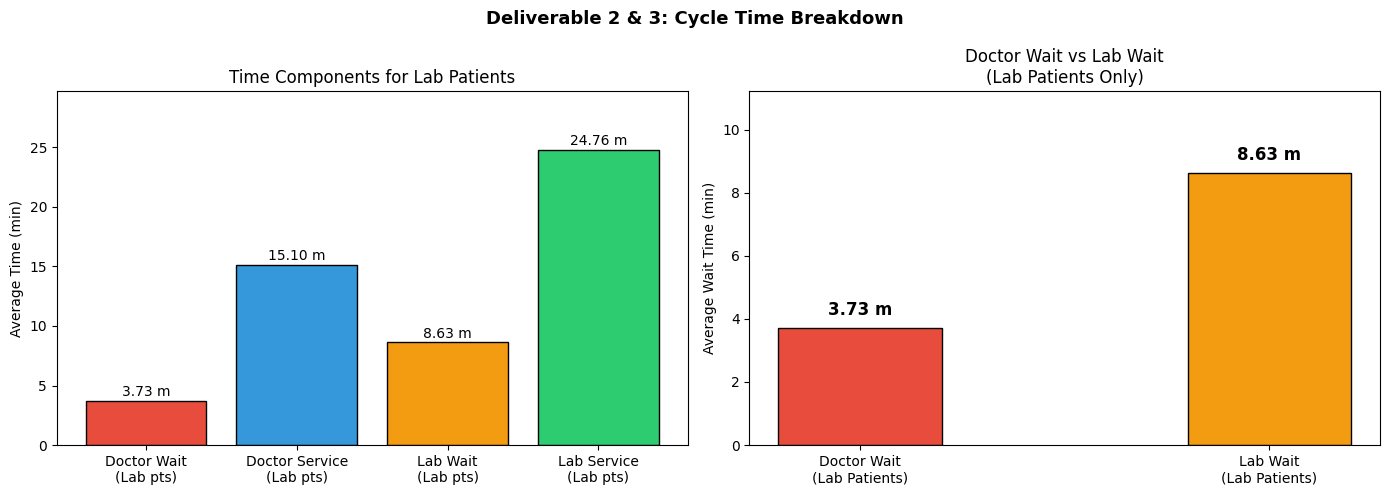

In [6]:
lab_patients = res[res['Needs_Lab']].copy()

print("=" * 65)
print("TOTAL CYCLE TIME ANALYSIS")
print("=" * 65)
print(f"Total patients:                          {len(res)}")
print(f"Patients requiring lab:                  {len(lab_patients)} ({100*len(lab_patients)/len(res):.1f}%)")
print(f"Avg Door-to-Door (Lab Patients):         {lab_patients['Door_to_Door'].mean():.2f} min")
print(f"Avg Door-to-Door (ALL Patients):         {res['Door_to_Door'].mean():.2f} min")
print()

avg_doc_wq_all   = res['Doc_Wq'].mean()
avg_doc_wq_lab   = lab_patients['Doc_Wq'].mean()   # doctor wait for lab-patients only
avg_lab_wq       = lab_patients['Lab_Wq'].mean()

print("WAIT TIME COMPARISON")
print("-" * 65)
print(f"Avg Doctor Wait (ALL patients):          {avg_doc_wq_all:.2f} min")
print(f"Avg Doctor Wait (Lab patients only):     {avg_doc_wq_lab:.2f} min")
print(f"Avg Lab Wait    (Lab patients only):     {avg_lab_wq:.2f} min")
print()
if avg_doc_wq_lab > avg_lab_wq:
    print(f"-> For lab patients, waiting for a DOCTOR is the bigger bottleneck "
          f"({avg_doc_wq_lab:.2f} min vs {avg_lab_wq:.2f} min lab wait).")
else:
    print(f"-> For lab patients, waiting for the LAB is the bigger bottleneck "
          f"({avg_lab_wq:.2f} min vs {avg_doc_wq_lab:.2f} min doctor wait).")

# --- Chart: component breakdown for lab patients ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: 4-component bar chart
components = ['Doctor Wait\n(Lab pts)', 'Doctor Service\n(Lab pts)', 'Lab Wait\n(Lab pts)', 'Lab Service\n(Lab pts)']
averages = [
    lab_patients['Doc_Wq'].mean(),
    lab_patients['Doc_Service'].mean(),
    lab_patients['Lab_Wq'].mean(),
    lab_patients['Lab_Service'].mean()
]
colors = ['#e74c3c', '#3498db', '#f39c12', '#2ecc71']
bars = axes[0].bar(components, averages, color=colors, edgecolor='black')
for bar, v in zip(bars, averages):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.4, f"{v:.2f} m", ha='center', fontsize=10)
axes[0].set_ylabel("Average Time (min)")
axes[0].set_title("Time Components for Lab Patients")
axes[0].set_ylim(0, max(averages) * 1.2)

# Right: Doctor Wait vs Lab Wait comparison (only lab patients)
labels = ['Doctor Wait\n(Lab Patients)', 'Lab Wait\n(Lab Patients)']
vals   = [avg_doc_wq_lab, avg_lab_wq]
bar2 = axes[1].bar(labels, vals, color=['#e74c3c', '#f39c12'], edgecolor='black', width=0.4)
for bar, v in zip(bar2, vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.4, f"{v:.2f} m", ha='center', fontsize=12, fontweight='bold')
axes[1].set_ylabel("Average Wait Time (min)")
axes[1].set_title("Doctor Wait vs Lab Wait\n(Lab Patients Only)")
axes[1].set_ylim(0, max(vals) * 1.3)

plt.suptitle("Deliverable 2 & 3: Cycle Time Breakdown", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# 6. Deliverable 4: Design for Performance

**Hospital Board Mandates:**
- Total System Lead Time (Avg Door-to-Door) ≤ 60 minutes  
- Doctor Utilization (ρ_dr) ≤ 85%

---

### Evaluation Strategy

We first check whether the current system (5 doctors, 3 lab machines) already meets both targets.

**Case A — Targets Already Met:**  
We find the maximum additional patient load the system can absorb before performance degrades.  
We do this by introducing a **Scale Factor (SF)**:

> `arrival_min_new = arrival_min_original × SF`

- SF = 1.0 → original dataset (baseline)
- SF < 1.0 → arrival times are *compressed*, so patients arrive **faster** (higher effective arrival rate λ)
- For example, SF = 0.8 means all arrivals happen in 80% of the original time window → arrival rate increases by **1/0.8 = 1.25×**

We sweep SF from 1.0 down to 0.5 in 20 steps. At each step we re-run the full simulation and check if targets are still met.  
The last SF value before targets are breached gives the **maximum sustainable arrival rate**.

**Case B — Targets Not Met:**  
We sweep different combinations of doctors and lab machines to find the minimum resource configuration that satisfies both targets.


In [7]:
current_lead_time = res['Door_to_Door'].mean()
current_doc_rho = metrics['doc_rho']

print(f"Current System (s_dr=5, s_lab=3):")
print(f"  Avg Lead Time: {current_lead_time:.2f} min (Target: <= 60.0)")
print(f"  Doctor Util:   {current_doc_rho*100:.2f}% (Target: <= 85.0%)")
print()

if current_lead_time <= 60 and current_doc_rho <= 0.85:
    print("Targets MET under current parameters!")
    print("Determining maximum additional arrivals by scaling inter-arrival times...")
    
    # Sweep scale factors from 1.0 down to 0.5 (which increases arrival rate up to 2x)
    scale_factors = np.linspace(1.0, 0.5, 20)
    max_lambda_scale = 1.0
    for sf in scale_factors:
        df_test = df.copy()
        df_test['arrival_min'] = df_test['arrival_min'] * sf
        res_test, met_test = simulate_network_flow(df_test, 5, 3)
        if res_test['Door_to_Door'].mean() > 60 or met_test['doc_rho'] > 0.85:
            break
        max_lambda_scale = sf
    
    current_lambda = 1000 / df['arrival_min'].max()
    new_lambda = current_lambda / max_lambda_scale
    additional_lambda = new_lambda - current_lambda
    multiplier = 1 / max_lambda_scale
    
    print(f"\n-> The system can handle up to an arrival rate λ = {new_lambda:.4f} pat/min")
    print(f"-> This means we can handle +{additional_lambda:.4f} additional arrivals per minute.")
    print(f"-> The arrival times were scaled by {max_lambda_scale:.2f} (a {multiplier:.2f}x increase in volume) before targets were breached.")

else:
    print("Targets NOT MET. Sweeping resources...")
    scenarios = []
    for d in range(5, 8):
        for l in range(3, 6):
            r, m = simulate_network_flow(df, s_dr=d, s_lab=l)
            lead = r['Door_to_Door'].mean()
            d_rho = m['doc_rho']
            meets = lead <= 60 and d_rho <= 0.85
            scenarios.append({'s_dr': d, 's_lab': l, 'LeadTime': lead, 'Doc_Rho': d_rho, 'Meets_Targets': meets})
            
    sc_df = pd.DataFrame(scenarios)
    display(sc_df)
    
    valid = sc_df[sc_df['Meets_Targets']]
    if not valid.empty:
        best = valid.sort_values(['s_dr', 's_lab']).iloc[0]
        print(f"\nMINIMUM RESOURCES TO MEET TARGETS: s_dr={int(best['s_dr'])}, s_lab={int(best['s_lab'])}")


Current System (s_dr=5, s_lab=3):
  Avg Lead Time: 32.78 min (Target: <= 60.0)
  Doctor Util:   74.43% (Target: <= 85.0%)

Targets MET under current parameters!
Determining maximum additional arrivals by scaling inter-arrival times...

-> The system can handle up to an arrival rate λ = 0.2823 pat/min
-> This means we can handle +0.0371 additional arrivals per minute.
-> The arrival times were scaled by 0.87 (a 1.15x increase in volume) before targets were breached.


# 7. Deliverable 5: Bottleneck Identification & Resource Allocation

1. Identify primary bottleneck comparing Traffic Intensity ($\rho$) for Doctors and Lab.
2. Budget allows hiring **ONE** more staff member: 6th Doctor vs 4th Lab Tech.


BOTTLENECK IDENTIFICATION
Doctor Traffic Intensity (rho_dr): 0.7443
Lab Traffic Intensity (rho_lab):   0.7926
-> Lab is the primary bottleneck (higher utilization).

SCENARIO COMPARISON (Budget for 1 hire):
Base (5 Dr, 3 Lab):       Lead Time = 32.78 min
Scenario A (6 Dr, 3 Lab): Lead Time = 30.26 min (Reduction: 2.51 min)
Scenario B (5 Dr, 4 Lab): Lead Time = 29.99 min (Reduction: 2.79 min)


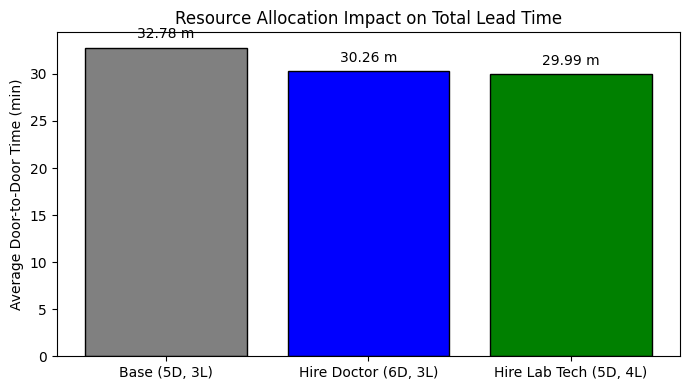


RECOMMENDATION: Hire a 4th Lab Technician to maximize total system lead time reduction.


In [8]:
print("=" * 60)
print("BOTTLENECK IDENTIFICATION")
print("=" * 60)

print(f"Doctor Traffic Intensity (rho_dr): {metrics['doc_rho']:.4f}")
print(f"Lab Traffic Intensity (rho_lab):   {metrics['lab_rho']:.4f}")

if metrics['doc_rho'] > metrics['lab_rho']:
    print("-> Doctors are the primary bottleneck (higher utilization).")
else:
    print("-> Lab is the primary bottleneck (higher utilization).")
print()

# Simulate Scenarios
print("SCENARIO COMPARISON (Budget for 1 hire):")
# Base
lead_base = res['Door_to_Door'].mean()

# Scenario A: 6 Doctors, 3 Lab
res_A, met_A = simulate_network_flow(df, s_dr=6, s_lab=3)
lead_A = res_A['Door_to_Door'].mean()

# Scenario B: 5 Doctors, 4 Lab
res_B, met_B = simulate_network_flow(df, s_dr=5, s_lab=4)
lead_B = res_B['Door_to_Door'].mean()

print(f"Base (5 Dr, 3 Lab):       Lead Time = {lead_base:.2f} min")
print(f"Scenario A (6 Dr, 3 Lab): Lead Time = {lead_A:.2f} min (Reduction: {lead_base - lead_A:.2f} min)")
print(f"Scenario B (5 Dr, 4 Lab): Lead Time = {lead_B:.2f} min (Reduction: {lead_base - lead_B:.2f} min)")

fig, ax = plt.subplots(figsize=(7, 4))
labels = ['Base (5D, 3L)', 'Hire Doctor (6D, 3L)', 'Hire Lab Tech (5D, 4L)']
times = [lead_base, lead_A, lead_B]

ax.bar(labels, times, color=['gray', 'blue', 'green'], edgecolor='black')
for i, v in enumerate(times):
    ax.text(i, v + 1, f"{v:.2f} m", ha='center')

ax.set_ylabel("Average Door-to-Door Time (min)")
ax.set_title("Resource Allocation Impact on Total Lead Time")
plt.tight_layout()
plt.show()

if lead_A < lead_B:
    print("\nRECOMMENDATION: Hire a 6th Doctor to maximize total system lead time reduction.")
else:
    print("\nRECOMMENDATION: Hire a 4th Lab Technician to maximize total system lead time reduction.")
